# 1. Load Data

In [1]:
# Global Import and Directories
import sys
sys.path.append("..")
import Setup
from Setup import *

Current working directory: /home/qusta100/STGNN/02_Code/05_Experiments


In [2]:
# Function to load models

def load_train_summaries_test_per_h(
    base_dir: str | Path,
    filename: str = "train_summary.json",
):

    base_dir = Path(base_dir)

    if not base_dir.exists():
        raise FileNotFoundError(f"base_dir not found: {base_dir}")

    json_files = sorted(base_dir.rglob(filename))
    if not json_files:
        raise FileNotFoundError(f"No {filename} found under {base_dir}")

    def safe_load_json(path: Path) -> dict:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)

    def flatten_hyperparams(hp: dict) -> dict:
        return {f"hp_{k}": v for k, v in hp.items()}

    rows_long = []

    for jf in json_files:
        data = safe_load_json(jf)

        mode = data.get("mode", None)
        seeds = data.get("seeds", [])
        hyperparams = data.get("hyperparams", {})
        hp_flat = flatten_hyperparams(hyperparams)

        per_seed = data.get("per_seed", [])
        if not per_seed:
            continue

        for seed_block in per_seed:
            seed = seed_block.get("seed", None)
            model_path = seed_block.get("model_path", None)
            preds_path = seed_block.get("preds_path", None)

            metrics = seed_block.get("metrics", {})
            test_per_h = metrics.get("test_per_h", {}) or {}

            for horizon_raw, vals in test_per_h.items():
                try:
                    horizon = int(horizon_raw)
                except Exception:
                    horizon = horizon_raw

                rows_long.append(
                    {
                        "folder": str(jf.parent),
                        "file": str(jf),
                        "mode": mode,
                        "seed": seed,
                        "seeds_in_file": ",".join(map(str, seeds)) if seeds else None,
                        "horizon": horizon,
                        "MAE": vals.get("MAE", None),
                        "RMSE": vals.get("RMSE", None),
                        "MAPE": vals.get("MAPE", None),
                        "model_path": model_path,
                        "preds_path": preds_path,
                        **hp_flat,
                    }
                )

    df_long = pd.DataFrame(rows_long)

    # sortieren (optional, aber praktisch)
    sort_cols = [c for c in ["hp_win_hour", "hp_win_day", "hp_win_week", "horizon", "seed"] if c in df_long.columns]
    if sort_cols and not df_long.empty:
        df_long = df_long.sort_values(sort_cols).reset_index(drop=True)


    return df_long

# 2. Thuringia

## 2.1. E5

Saved plots to: /home/qusta100/STGNN/03_Graphs/04_Experiments/01_Experiments_Evaluation_HP/01_Thuringia/01_E5


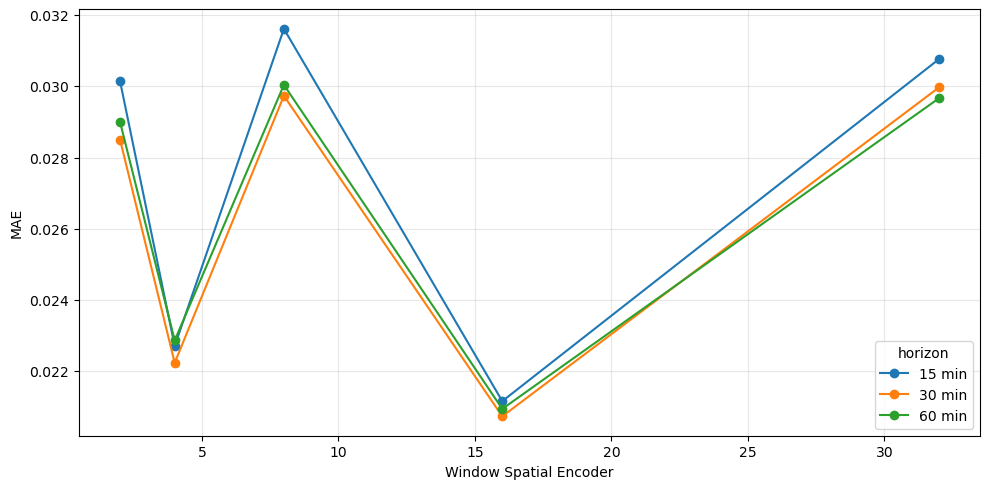

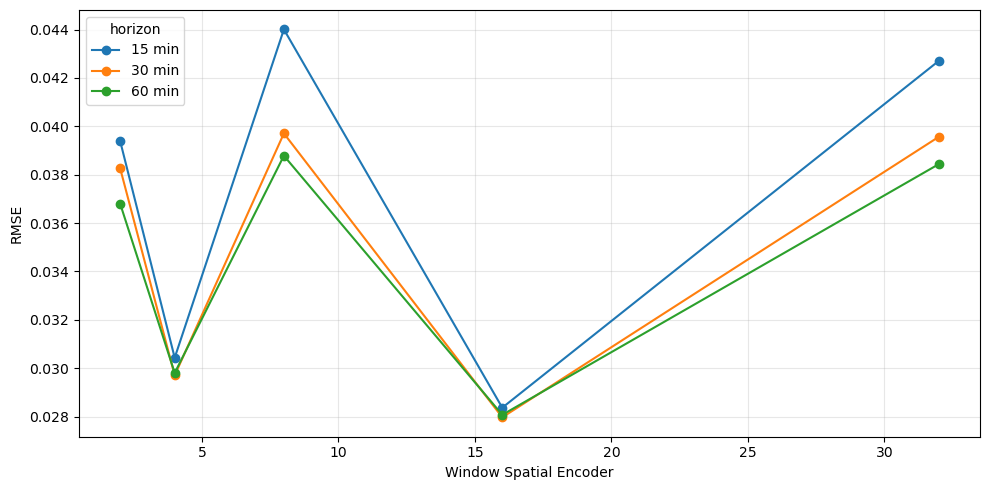

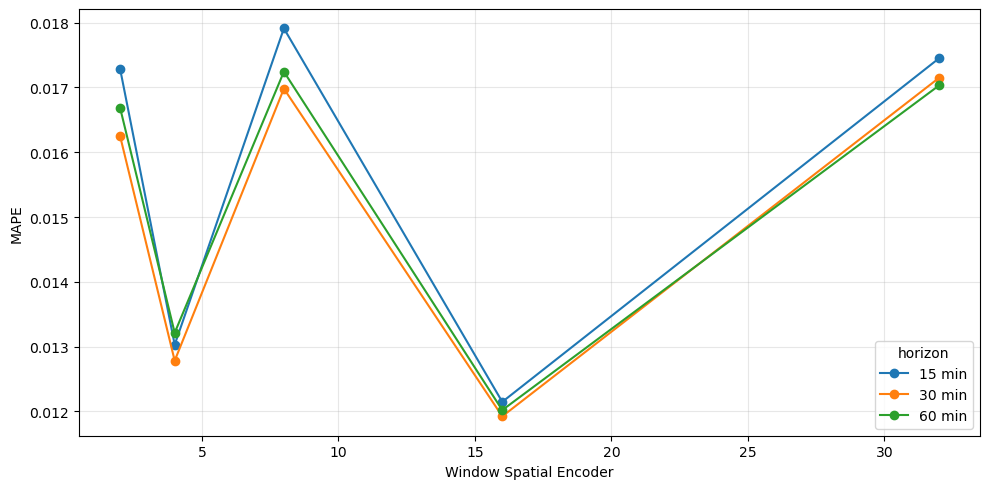

In [14]:
# ============================================================
# Window Size Spatial Encoder
# ============================================================
WindowSize_Spatial = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "01_WindowSize_Spatial"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)


WindowSize_Spatial_df = load_train_summaries_test_per_h(WindowSize_Spatial)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Spatial_df["horizon"].unique()):
        tmp = WindowSize_Spatial_df[WindowSize_Spatial_df["horizon"] == h].sort_values("hp_win_hour")
        plt.plot(tmp["hp_win_hour"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Spatial Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Spatial_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

Saved plots to: /home/qusta100/STGNN/03_Graphs/04_Experiments/01_Experiments_Evaluation_HP/01_Thuringia/01_E5


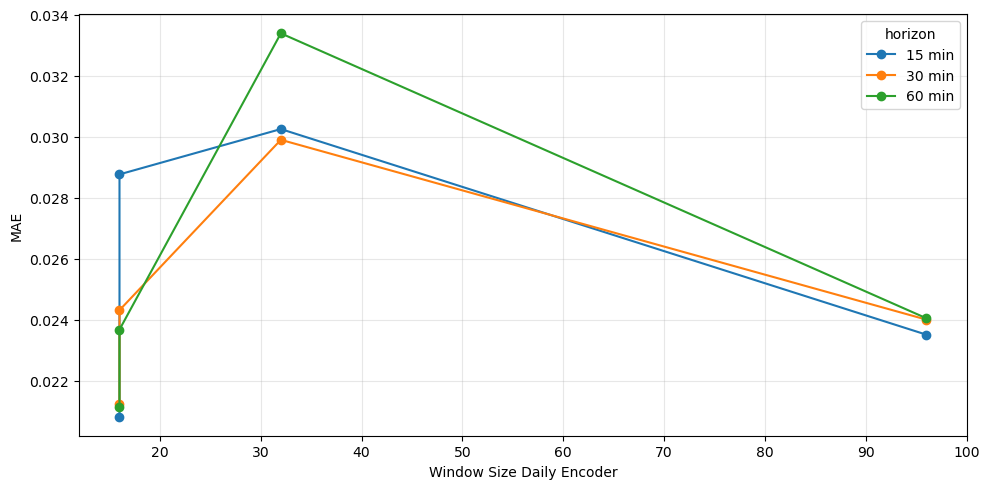

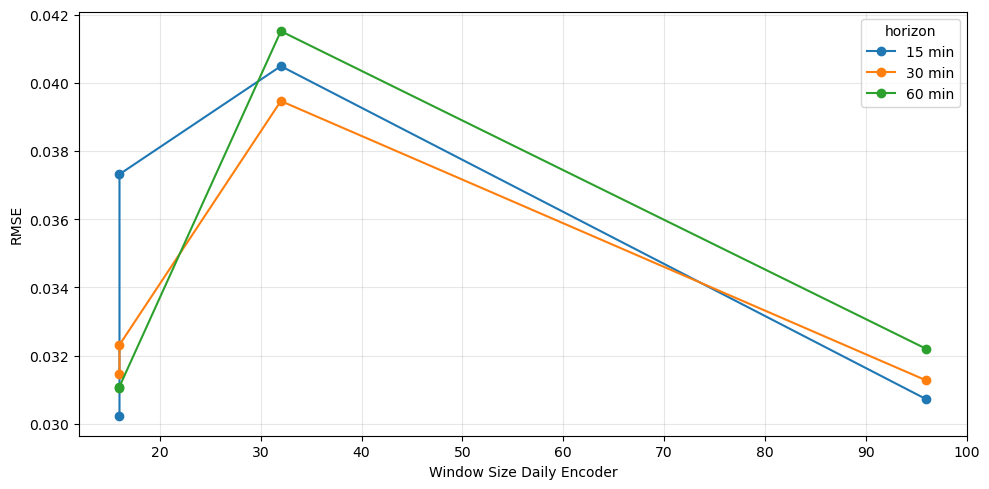

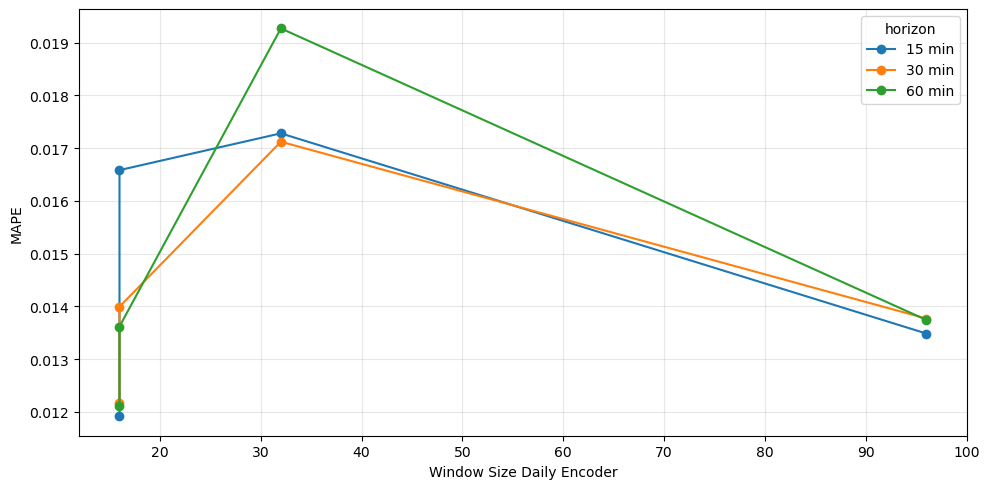

In [15]:
# ============================================================
# Window Size Daily Encoder
# ============================================================
WindowSize_Day = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "02_WindowSize_Day"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)

WindowSize_Day_df = load_train_summaries_test_per_h(WindowSize_Day)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Day_df["horizon"].unique()):
        tmp = WindowSize_Day_df[WindowSize_Day_df["horizon"] == h].sort_values("hp_win_day")
        plt.plot(tmp["hp_win_day"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Daily Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"02_WindowSize_Day_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

Saved plots to: /home/qusta100/STGNN/03_Graphs/04_Experiments/01_Experiments_Evaluation_HP/01_Thuringia/01_E5


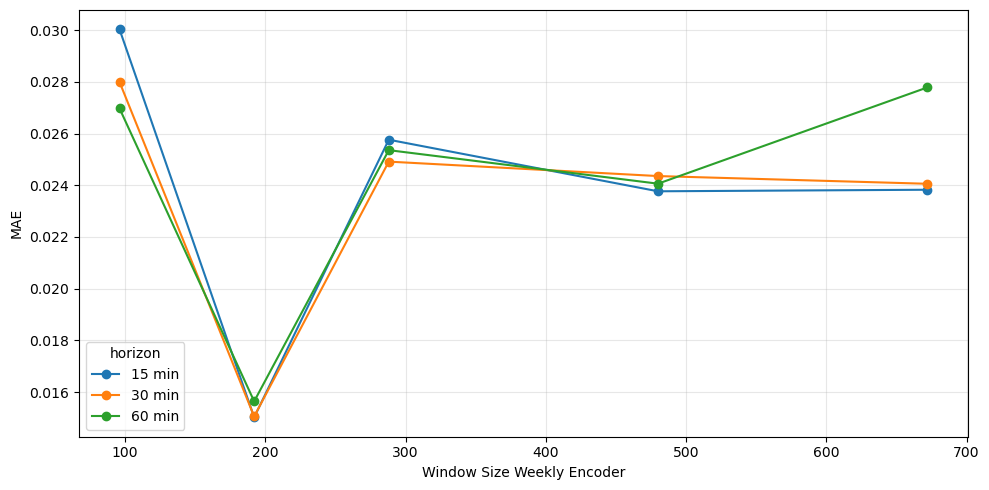

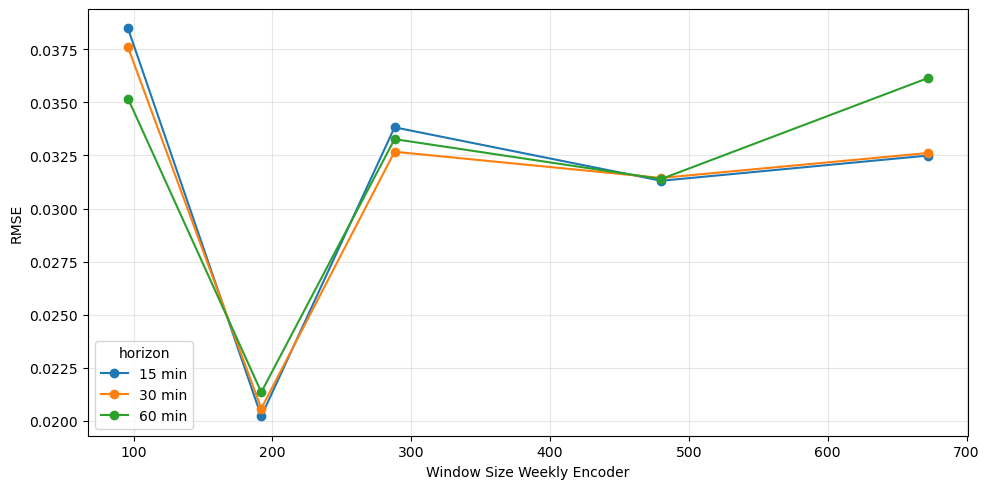

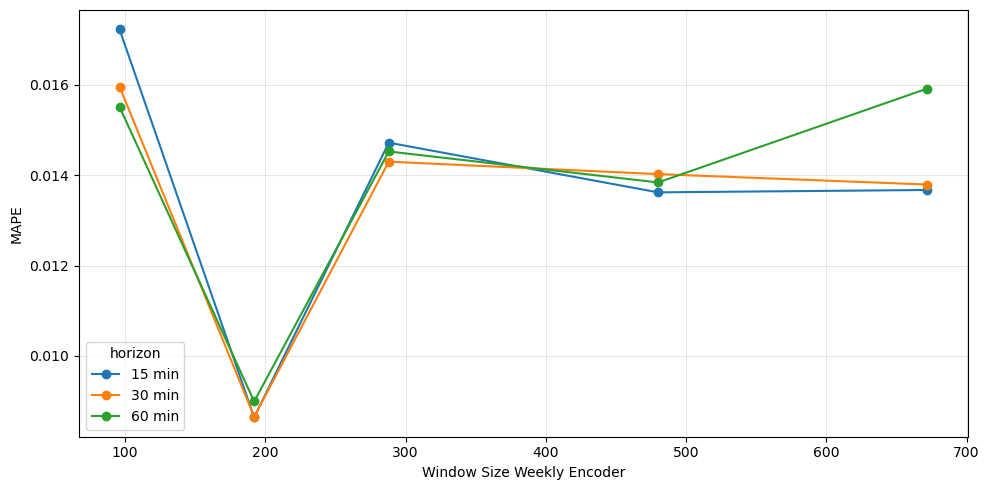

In [16]:
# ============================================================
# Window Size Weekly Encoder
# ============================================================
WindowSize_Week = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "03_WindowSize_Week"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)

WindowSize_Week_df = load_train_summaries_test_per_h(WindowSize_Week)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Week_df["horizon"].unique()):
        tmp = WindowSize_Week_df[WindowSize_Week_df["horizon"] == h].sort_values("hp_win_week")
        plt.plot(tmp["hp_win_week"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Weekly Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Week_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

Saved plots to: /home/qusta100/STGNN/03_Graphs/04_Experiments/01_Experiments_Evaluation_HP/01_Thuringia/01_E5


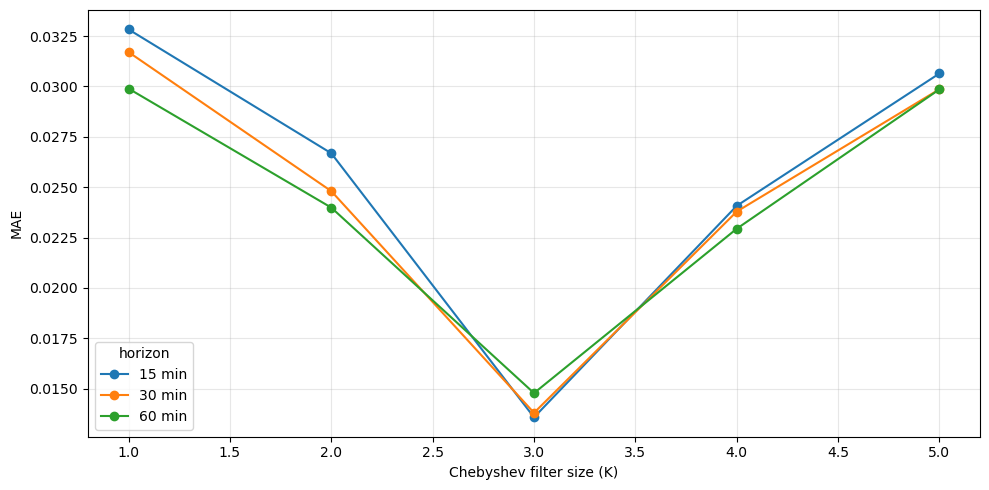

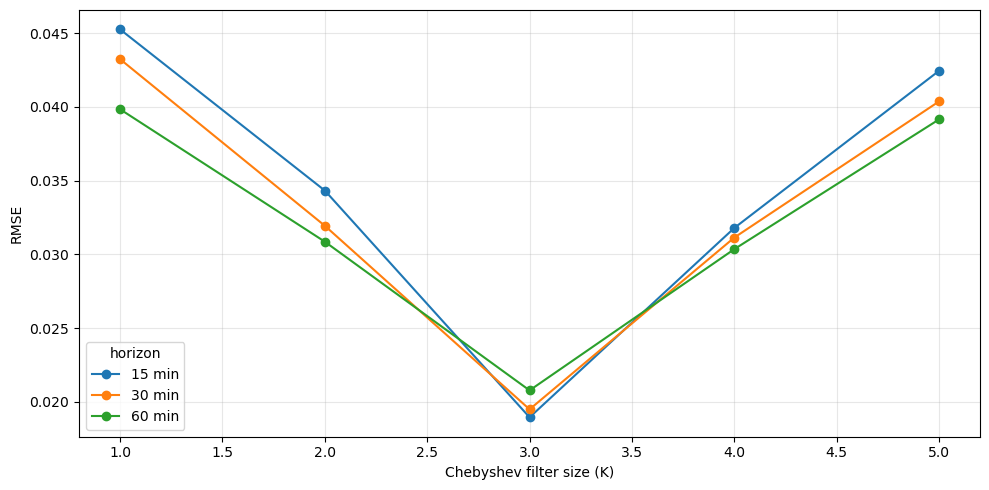

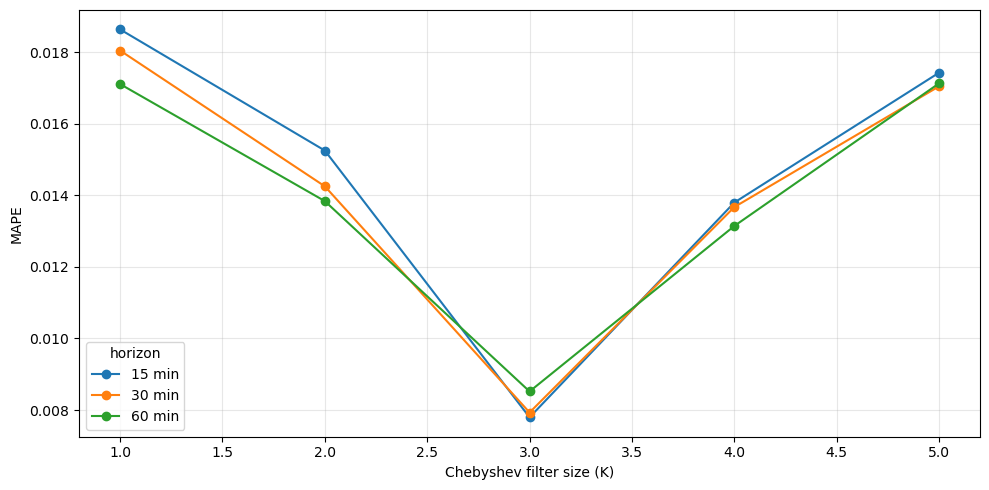

In [17]:
# ============================================================
# Chebyshev Filter Size
# ============================================================
Chebyshev_FilterSize = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "04_Chebyshev_FilterSize"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)

Chebyshev_FilterSize_df = load_train_summaries_test_per_h(Chebyshev_FilterSize)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Chebyshev_FilterSize_df["horizon"].unique()):
        tmp = Chebyshev_FilterSize_df[Chebyshev_FilterSize_df["horizon"] == h].sort_values("hp_cheb_K")
        plt.plot(tmp["hp_cheb_K"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Chebyshev filter size (K)")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Chebyshev_FilterSize_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

Saved plots to: /home/qusta100/STGNN/03_Graphs/04_Experiments/01_Experiments_Evaluation_HP/01_Thuringia/01_E5


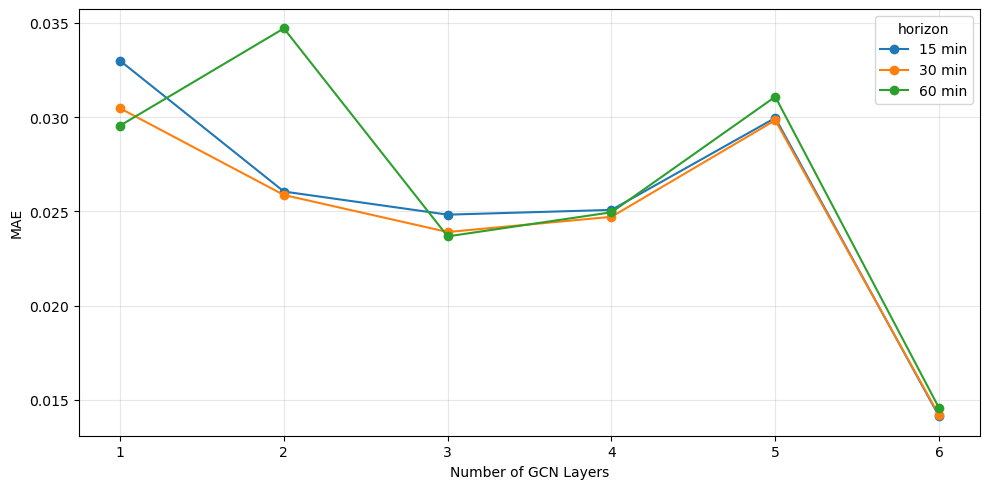

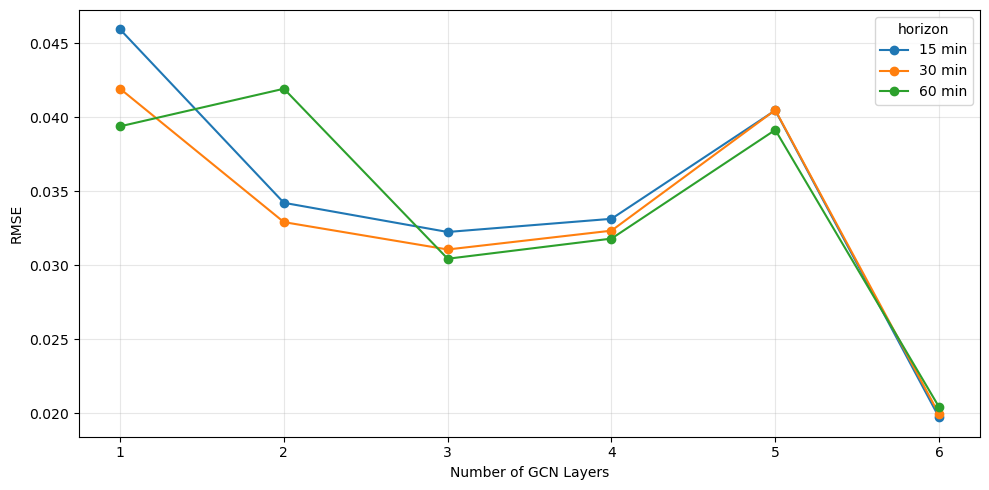

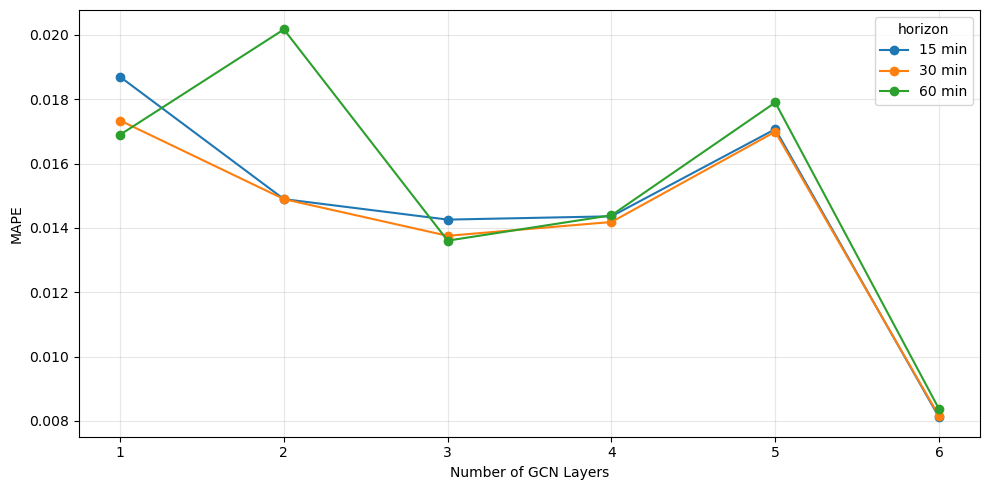

In [18]:
# ============================================================
# GCN Layers
# ============================================================
GCN_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "05_GCN_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)

GCN_Layers_df = load_train_summaries_test_per_h(GCN_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(GCN_Layers_df["horizon"].unique()):
        tmp = GCN_Layers_df[GCN_Layers_df["horizon"] == h].sort_values("hp_cheb_layers")
        plt.plot(tmp["hp_cheb_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of GCN Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"GCN_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

Saved plots to: /home/qusta100/STGNN/03_Graphs/04_Experiments/01_Experiments_Evaluation_HP/01_Thuringia/01_E5


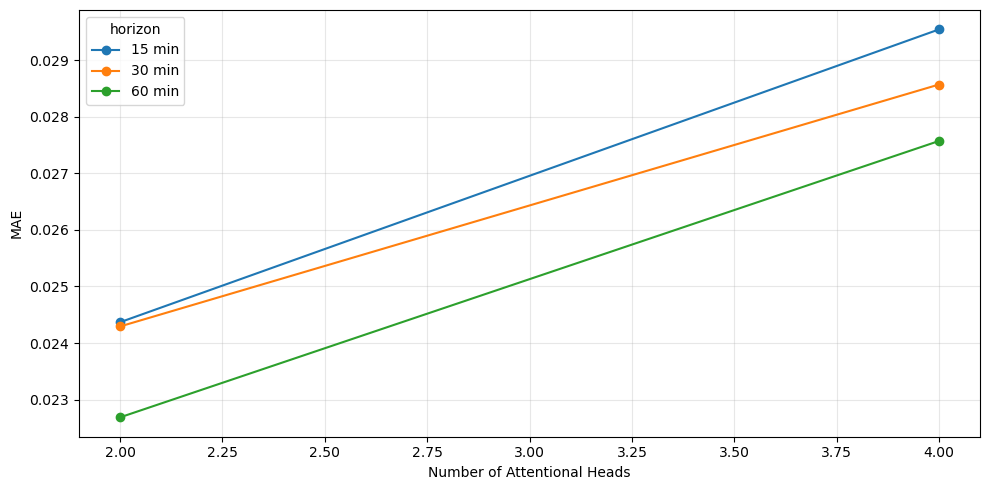

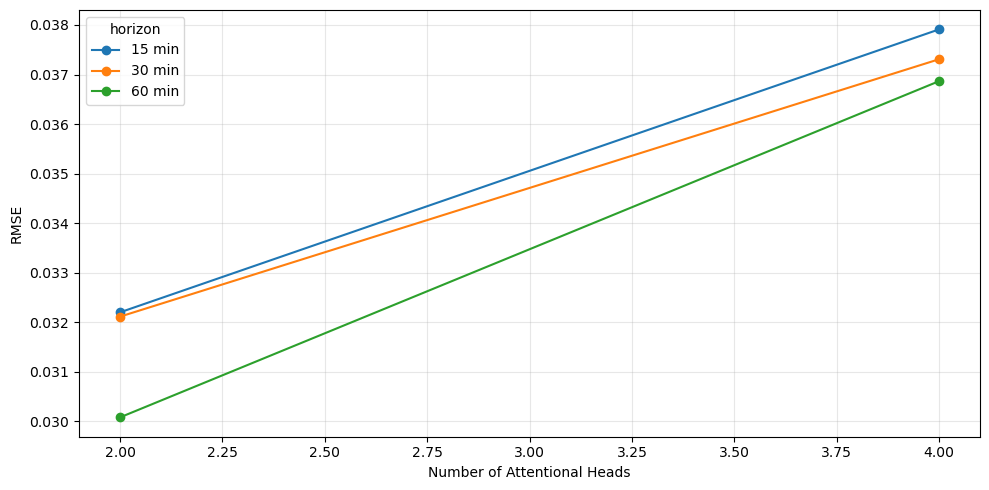

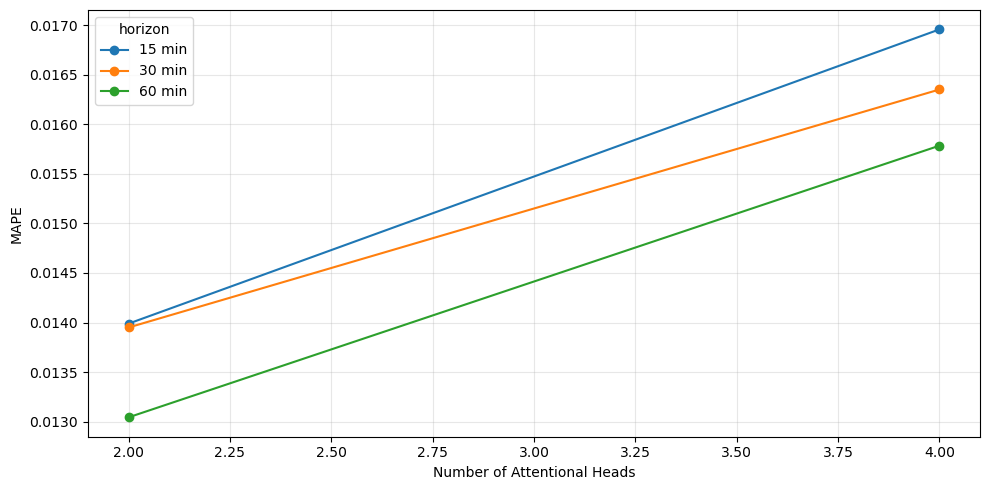

In [19]:
# ============================================================
# Attentional Heads
# ============================================================
Attentional_Heads = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "06_Attentional_Heads"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)

Attentional_Heads_df = load_train_summaries_test_per_h(Attentional_Heads)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Attentional_Heads_df["horizon"].unique()):
        tmp = Attentional_Heads_df[Attentional_Heads_df["horizon"] == h].sort_values("hp_attn_heads")
        plt.plot(tmp["hp_attn_heads"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attentional Heads")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Attentional_Heads_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Temporal Decoder Attention Layers
# ============================================================
Temporal_Decoder_Attention_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
    / "07_Temporal_Decoder_Attention_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "01_E5"
)

Temporal_Decoder_Attention_Layers_df = load_train_summaries_test_per_h(Temporal_Decoder_Attention_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Temporal_Decoder_Attention_Layers_df["horizon"].unique()):
        tmp = Temporal_Decoder_Attention_Layers_df[Temporal_Decoder_Attention_Layers_df["horizon"] == h].sort_values("hp_temporal_attn_layers")
        plt.plot(tmp["hp_temporal_attn_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attention Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Temporal_Decoder_Attention_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

## 2.2. E10

In [ ]:
# ============================================================
# Window Size Spatial Encoder
# ============================================================
WindowSize_Spatial = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "01_WindowSize_Spatial"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

WindowSize_Spatial_df = load_train_summaries_test_per_h(WindowSize_Spatial)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Spatial_df["horizon"].unique()):
        tmp = WindowSize_Spatial_df[WindowSize_Spatial_df["horizon"] == h].sort_values("hp_win_hour")
        plt.plot(tmp["hp_win_hour"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Spatial Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Spatial_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Daily Encoder
# ============================================================
WindowSize_Day = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "02_WindowSize_Day"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

WindowSize_Day_df = load_train_summaries_test_per_h(WindowSize_Day)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Day_df["horizon"].unique()):
        tmp = WindowSize_Day_df[WindowSize_Day_df["horizon"] == h].sort_values("hp_win_day")
        plt.plot(tmp["hp_win_day"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Daily Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"02_WindowSize_Day_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Weekly Encoder
# ============================================================
WindowSize_Week = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "03_WindowSize_Week"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

WindowSize_Week_df = load_train_summaries_test_per_h(WindowSize_Week)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Week_df["horizon"].unique()):
        tmp = WindowSize_Week_df[WindowSize_Week_df["horizon"] == h].sort_values("hp_win_week")
        plt.plot(tmp["hp_win_week"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Weekly Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Week_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Chebyshev Filter Size
# ============================================================
Chebyshev_FilterSize = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "04_Chebyshev_FilterSize"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

Chebyshev_FilterSize_df = load_train_summaries_test_per_h(Chebyshev_FilterSize)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Chebyshev_FilterSize_df["horizon"].unique()):
        tmp = Chebyshev_FilterSize_df[Chebyshev_FilterSize_df["horizon"] == h].sort_values("hp_cheb_K")
        plt.plot(tmp["hp_cheb_K"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Chebyshev filter size (K)")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Chebyshev_FilterSize_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# GCN Layers
# ============================================================
GCN_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "05_GCN_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

GCN_Layers_df = load_train_summaries_test_per_h(GCN_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(GCN_Layers_df["horizon"].unique()):
        tmp = GCN_Layers_df[GCN_Layers_df["horizon"] == h].sort_values("hp_cheb_layers")
        plt.plot(tmp["hp_cheb_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of GCN Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"GCN_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Attentional Heads
# ============================================================
Attentional_Heads = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "06_Attentional_Heads"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

Attentional_Heads_df = load_train_summaries_test_per_h(Attentional_Heads)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Attentional_Heads_df["horizon"].unique()):
        tmp = Attentional_Heads_df[Attentional_Heads_df["horizon"] == h].sort_values("hp_attn_heads")
        plt.plot(tmp["hp_attn_heads"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attentional Heads")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Attentional_Heads_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Temporal Decoder Attention Layers
# ============================================================
Temporal_Decoder_Attention_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
    / "07_Temporal_Decoder_Attention_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "02_E10"
)

Temporal_Decoder_Attention_Layers_df = load_train_summaries_test_per_h(Temporal_Decoder_Attention_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Temporal_Decoder_Attention_Layers_df["horizon"].unique()):
        tmp = Temporal_Decoder_Attention_Layers_df[Temporal_Decoder_Attention_Layers_df["horizon"] == h].sort_values("hp_temporal_attn_layers")
        plt.plot(tmp["hp_temporal_attn_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attention Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Temporal_Decoder_Attention_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

## 2.3. Diesel

In [ ]:
# ============================================================
# Window Size Spatial Encoder
# ============================================================
WindowSize_Spatial = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "01_WindowSize_Spatial"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

WindowSize_Spatial_df = load_train_summaries_test_per_h(WindowSize_Spatial)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Spatial_df["horizon"].unique()):
        tmp = WindowSize_Spatial_df[WindowSize_Spatial_df["horizon"] == h].sort_values("hp_win_hour")
        plt.plot(tmp["hp_win_hour"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Spatial Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Spatial_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Daily Encoder
# ============================================================
WindowSize_Day = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "02_WindowSize_Day"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

WindowSize_Day_df = load_train_summaries_test_per_h(WindowSize_Day)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Day_df["horizon"].unique()):
        tmp = WindowSize_Day_df[WindowSize_Day_df["horizon"] == h].sort_values("hp_win_day")
        plt.plot(tmp["hp_win_day"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Daily Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"02_WindowSize_Day_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Weekly Encoder
# ============================================================
WindowSize_Week = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "03_WindowSize_Week"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

WindowSize_Week_df = load_train_summaries_test_per_h(WindowSize_Week)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Week_df["horizon"].unique()):
        tmp = WindowSize_Week_df[WindowSize_Week_df["horizon"] == h].sort_values("hp_win_week")
        plt.plot(tmp["hp_win_week"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Weekly Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Week_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Chebyshev Filter Size
# ============================================================
Chebyshev_FilterSize = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "04_Chebyshev_FilterSize"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

Chebyshev_FilterSize_df = load_train_summaries_test_per_h(Chebyshev_FilterSize)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Chebyshev_FilterSize_df["horizon"].unique()):
        tmp = Chebyshev_FilterSize_df[Chebyshev_FilterSize_df["horizon"] == h].sort_values("hp_cheb_K")
        plt.plot(tmp["hp_cheb_K"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Chebyshev filter size (K)")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Chebyshev_FilterSize_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# GCN Layers
# ============================================================
GCN_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "05_GCN_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

GCN_Layers_df = load_train_summaries_test_per_h(GCN_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(GCN_Layers_df["horizon"].unique()):
        tmp = GCN_Layers_df[GCN_Layers_df["horizon"] == h].sort_values("hp_cheb_layers")
        plt.plot(tmp["hp_cheb_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of GCN Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"GCN_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Attentional Heads
# ============================================================
Attentional_Heads = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "06_Attentional_Heads"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

Attentional_Heads_df = load_train_summaries_test_per_h(Attentional_Heads)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Attentional_Heads_df["horizon"].unique()):
        tmp = Attentional_Heads_df[Attentional_Heads_df["horizon"] == h].sort_values("hp_attn_heads")
        plt.plot(tmp["hp_attn_heads"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attentional Heads")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Attentional_Heads_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Temporal Decoder Attention Layers
# ============================================================
Temporal_Decoder_Attention_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
    / "07_Temporal_Decoder_Attention_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "01_Thuringia"
    / "03_Diesel"
)

Temporal_Decoder_Attention_Layers_df = load_train_summaries_test_per_h(Temporal_Decoder_Attention_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Temporal_Decoder_Attention_Layers_df["horizon"].unique()):
        tmp = Temporal_Decoder_Attention_Layers_df[Temporal_Decoder_Attention_Layers_df["horizon"] == h].sort_values("hp_temporal_attn_layers")
        plt.plot(tmp["hp_temporal_attn_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attention Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Temporal_Decoder_Attention_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

# 3. Hesse

## 3.1. E5

In [ ]:
# ============================================================
# Window Size Spatial Encoder
# ============================================================
WindowSize_Spatial = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "01_WindowSize_Spatial"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

WindowSize_Spatial_df = load_train_summaries_test_per_h(WindowSize_Spatial)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Spatial_df["horizon"].unique()):
        tmp = WindowSize_Spatial_df[WindowSize_Spatial_df["horizon"] == h].sort_values("hp_win_hour")
        plt.plot(tmp["hp_win_hour"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Spatial Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Spatial_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Daily Encoder
# ============================================================
WindowSize_Day = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "02_WindowSize_Day"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

WindowSize_Day_df = load_train_summaries_test_per_h(WindowSize_Day)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Day_df["horizon"].unique()):
        tmp = WindowSize_Day_df[WindowSize_Day_df["horizon"] == h].sort_values("hp_win_day")
        plt.plot(tmp["hp_win_day"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Daily Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"02_WindowSize_Day_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Weekly Encoder
# ============================================================
WindowSize_Week = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "03_WindowSize_Week"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

WindowSize_Week_df = load_train_summaries_test_per_h(WindowSize_Week)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Week_df["horizon"].unique()):
        tmp = WindowSize_Week_df[WindowSize_Week_df["horizon"] == h].sort_values("hp_win_week")
        plt.plot(tmp["hp_win_week"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Weekly Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Week_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Chebyshev Filter Size
# ============================================================
Chebyshev_FilterSize = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "04_Chebyshev_FilterSize"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

Chebyshev_FilterSize_df = load_train_summaries_test_per_h(Chebyshev_FilterSize)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Chebyshev_FilterSize_df["horizon"].unique()):
        tmp = Chebyshev_FilterSize_df[Chebyshev_FilterSize_df["horizon"] == h].sort_values("hp_cheb_K")
        plt.plot(tmp["hp_cheb_K"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Chebyshev filter size (K)")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Chebyshev_FilterSize_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# GCN Layers
# ============================================================
GCN_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "05_GCN_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

GCN_Layers_df = load_train_summaries_test_per_h(GCN_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(GCN_Layers_df["horizon"].unique()):
        tmp = GCN_Layers_df[GCN_Layers_df["horizon"] == h].sort_values("hp_cheb_layers")
        plt.plot(tmp["hp_cheb_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of GCN Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"GCN_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Attentional Heads
# ============================================================
Attentional_Heads = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "06_Attentional_Heads"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

Attentional_Heads_df = load_train_summaries_test_per_h(Attentional_Heads)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Attentional_Heads_df["horizon"].unique()):
        tmp = Attentional_Heads_df[Attentional_Heads_df["horizon"] == h].sort_values("hp_attn_heads")
        plt.plot(tmp["hp_attn_heads"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attentional Heads")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Attentional_Heads_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Temporal Decoder Attention Layers
# ============================================================
Temporal_Decoder_Attention_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
    / "07_Temporal_Decoder_Attention_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "01_E5"
)

Temporal_Decoder_Attention_Layers_df = load_train_summaries_test_per_h(Temporal_Decoder_Attention_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Temporal_Decoder_Attention_Layers_df["horizon"].unique()):
        tmp = Temporal_Decoder_Attention_Layers_df[Temporal_Decoder_Attention_Layers_df["horizon"] == h].sort_values("hp_temporal_attn_layers")
        plt.plot(tmp["hp_temporal_attn_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attention Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Temporal_Decoder_Attention_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

## 3.2. E10

In [ ]:
# ============================================================
# Window Size Spatial Encoder
# ============================================================
WindowSize_Spatial = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "01_WindowSize_Spatial"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

WindowSize_Spatial_df = load_train_summaries_test_per_h(WindowSize_Spatial)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Spatial_df["horizon"].unique()):
        tmp = WindowSize_Spatial_df[WindowSize_Spatial_df["horizon"] == h].sort_values("hp_win_hour")
        plt.plot(tmp["hp_win_hour"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Spatial Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Spatial_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Daily Encoder
# ============================================================
WindowSize_Day = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "02_WindowSize_Day"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

WindowSize_Day_df = load_train_summaries_test_per_h(WindowSize_Day)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Day_df["horizon"].unique()):
        tmp = WindowSize_Day_df[WindowSize_Day_df["horizon"] == h].sort_values("hp_win_day")
        plt.plot(tmp["hp_win_day"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Daily Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"02_WindowSize_Day_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Weekly Encoder
# ============================================================
WindowSize_Week = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "03_WindowSize_Week"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

WindowSize_Week_df = load_train_summaries_test_per_h(WindowSize_Week)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Week_df["horizon"].unique()):
        tmp = WindowSize_Week_df[WindowSize_Week_df["horizon"] == h].sort_values("hp_win_week")
        plt.plot(tmp["hp_win_week"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Weekly Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Week_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Chebyshev Filter Size
# ============================================================
Chebyshev_FilterSize = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "04_Chebyshev_FilterSize"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

Chebyshev_FilterSize_df = load_train_summaries_test_per_h(Chebyshev_FilterSize)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Chebyshev_FilterSize_df["horizon"].unique()):
        tmp = Chebyshev_FilterSize_df[Chebyshev_FilterSize_df["horizon"] == h].sort_values("hp_cheb_K")
        plt.plot(tmp["hp_cheb_K"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Chebyshev filter size (K)")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Chebyshev_FilterSize_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# GCN Layers
# ============================================================
GCN_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "05_GCN_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

GCN_Layers_df = load_train_summaries_test_per_h(GCN_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(GCN_Layers_df["horizon"].unique()):
        tmp = GCN_Layers_df[GCN_Layers_df["horizon"] == h].sort_values("hp_cheb_layers")
        plt.plot(tmp["hp_cheb_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of GCN Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"GCN_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Attentional Heads
# ============================================================
Attentional_Heads = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "06_Attentional_Heads"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

Attentional_Heads_df = load_train_summaries_test_per_h(Attentional_Heads)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Attentional_Heads_df["horizon"].unique()):
        tmp = Attentional_Heads_df[Attentional_Heads_df["horizon"] == h].sort_values("hp_attn_heads")
        plt.plot(tmp["hp_attn_heads"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attentional Heads")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Attentional_Heads_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Temporal Decoder Attention Layers
# ============================================================
Temporal_Decoder_Attention_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
    / "07_Temporal_Decoder_Attention_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "02_E10"
)

Temporal_Decoder_Attention_Layers_df = load_train_summaries_test_per_h(Temporal_Decoder_Attention_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Temporal_Decoder_Attention_Layers_df["horizon"].unique()):
        tmp = Temporal_Decoder_Attention_Layers_df[Temporal_Decoder_Attention_Layers_df["horizon"] == h].sort_values("hp_temporal_attn_layers")
        plt.plot(tmp["hp_temporal_attn_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attention Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Temporal_Decoder_Attention_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

## 3.3. Diesel

In [ ]:
# ============================================================
# Window Size Spatial Encoder
# ============================================================
WindowSize_Spatial = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "01_WindowSize_Spatial"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

WindowSize_Spatial_df = load_train_summaries_test_per_h(WindowSize_Spatial)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Spatial_df["horizon"].unique()):
        tmp = WindowSize_Spatial_df[WindowSize_Spatial_df["horizon"] == h].sort_values("hp_win_hour")
        plt.plot(tmp["hp_win_hour"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Spatial Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Spatial_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Daily Encoder
# ============================================================
WindowSize_Day = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "02_WindowSize_Day"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

WindowSize_Day_df = load_train_summaries_test_per_h(WindowSize_Day)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Day_df["horizon"].unique()):
        tmp = WindowSize_Day_df[WindowSize_Day_df["horizon"] == h].sort_values("hp_win_day")
        plt.plot(tmp["hp_win_day"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Daily Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"02_WindowSize_Day_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Window Size Weekly Encoder
# ============================================================
WindowSize_Week = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "03_WindowSize_Week"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

WindowSize_Week_df = load_train_summaries_test_per_h(WindowSize_Week)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(WindowSize_Week_df["horizon"].unique()):
        tmp = WindowSize_Week_df[WindowSize_Week_df["horizon"] == h].sort_values("hp_win_week")
        plt.plot(tmp["hp_win_week"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Window Size Weekly Encoder")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"WindowSize_Week_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Chebyshev Filter Size
# ============================================================
Chebyshev_FilterSize = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "04_Chebyshev_FilterSize"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

Chebyshev_FilterSize_df = load_train_summaries_test_per_h(Chebyshev_FilterSize)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Chebyshev_FilterSize_df["horizon"].unique()):
        tmp = Chebyshev_FilterSize_df[Chebyshev_FilterSize_df["horizon"] == h].sort_values("hp_cheb_K")
        plt.plot(tmp["hp_cheb_K"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Chebyshev filter size (K)")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Chebyshev_FilterSize_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# GCN Layers
# ============================================================
GCN_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "05_GCN_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

GCN_Layers_df = load_train_summaries_test_per_h(GCN_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(GCN_Layers_df["horizon"].unique()):
        tmp = GCN_Layers_df[GCN_Layers_df["horizon"] == h].sort_values("hp_cheb_layers")
        plt.plot(tmp["hp_cheb_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of GCN Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"GCN_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Attentional Heads
# ============================================================
Attentional_Heads = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "06_Attentional_Heads"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

Attentional_Heads_df = load_train_summaries_test_per_h(Attentional_Heads)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Attentional_Heads_df["horizon"].unique()):
        tmp = Attentional_Heads_df[Attentional_Heads_df["horizon"] == h].sort_values("hp_attn_heads")
        plt.plot(tmp["hp_attn_heads"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attentional Heads")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Attentional_Heads_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")

In [ ]:
# ============================================================
# Temporal Decoder Attention Layers
# ============================================================
Temporal_Decoder_Attention_Layers = (
    Setup.HOME_ROOT
    / "04_Results"
    / "01_Temporary"
    / "05_Predictions"
    / "05_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
    / "07_Temporal_Decoder_Attention_Layers"
)
out_dir = (
    Setup.HOME_ROOT
    / "03_Graphs"
    / "04_Experiments"
    / "01_Experiments_Evaluation_HP"
    / "02_Hesse"
    / "03_Diesel"
)

Temporal_Decoder_Attention_Layers_df = load_train_summaries_test_per_h(Temporal_Decoder_Attention_Layers)
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(10, 5))

    for h in sorted(Temporal_Decoder_Attention_Layers_df["horizon"].unique()):
        tmp = Temporal_Decoder_Attention_Layers_df[Temporal_Decoder_Attention_Layers_df["horizon"] == h].sort_values("hp_temporal_attn_layers")
        plt.plot(tmp["hp_temporal_attn_layers"], tmp[metric], marker="o", label=f"{h*15} min")

    plt.xlabel("Number of Attention Layers")
    plt.ylabel(metric)
    plt.legend(title="horizon")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = out_dir / f"Temporal_Decoder_Attention_Layers_{metric}.png"
    plt.savefig(out_path, dpi=300)
    #plt.show()

print(f"Saved plots to: {out_dir}")